<font size=6> <b>lec06. [실습] Titanic - DataFrame

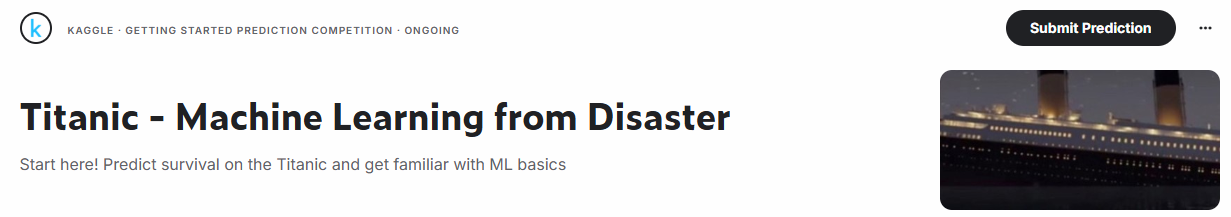
* ref : https://www.kaggle.com/competitions/hw5-titantic-competition-cs189sp23

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#    패키지   모듈                   메서드  
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>Data Load

In [2]:
train = pd.read_csv("./data/titanic/train.csv")
test = pd.read_csv("./data/titanic/test.csv")
submission = pd.read_csv("./data/titanic/gender_submission.csv")

In [6]:
train.drop('Survived', axis=1)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [9]:
train_test = pd.concat([train, test], axis=0)

In [11]:
train.shape, test.shape, train_test.shape

((891, 12), (418, 11), (1309, 12))

In [14]:
train_test.iloc[889:894,:]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
889,890,1.0,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0.0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q
0,892,NaN,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,NaN,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,NaN,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


## 컬럼 소문자 변경

In [15]:
train_test.columns = train_test.columns.str.lower()

In [16]:
train_test.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

## 구조 : info()

In [17]:
train_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  1309 non-null   int64  
 1   survived     891 non-null    float64
 2   pclass       1309 non-null   int64  
 3   name         1309 non-null   object 
 4   sex          1309 non-null   object 
 5   age          1046 non-null   float64
 6   sibsp        1309 non-null   int64  
 7   parch        1309 non-null   int64  
 8   ticket       1309 non-null   object 
 9   fare         1308 non-null   float64
 10  cabin        295 non-null    object 
 11  embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 132.9+ KB


In [18]:
train_test['survived'].value_counts()

survived
0.0    549
1.0    342
Name: count, dtype: int64

# <b>EDA (Exploratory Data Analysis)
* 시각화(visualizations), 통계(statistics)

## 데이터 분포도

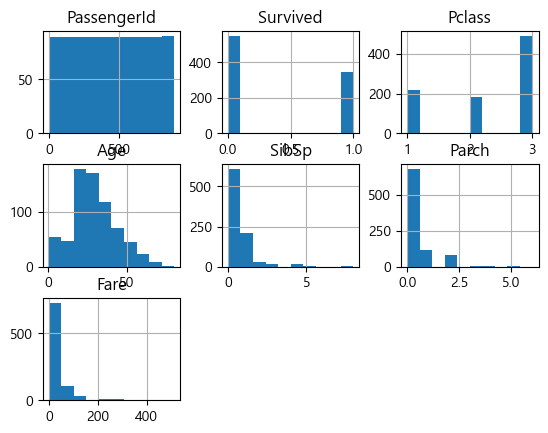

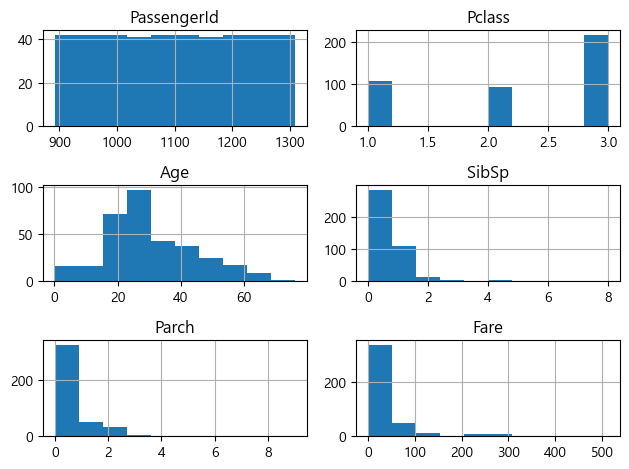

In [20]:
train.hist()
test.hist()
plt.tight_layout()
plt.show()

# <b>전처리 & 가공
* Feature Engineering

<pre>

'cabin'           : 생존관계 확인 vs. 'survived'  --> drop
'embarked'        : 생존관계   vs. 'survived'
                    결측처리(최빈), 인코딩

바이닝(구간화)     : 'age'
호칭자르기         : 'name'
결측처리           : 'age'(평균...??), 'embarked'(최빈)
    
버리기            : 'passengerid', 'ticket' ....  'cabin'    
인코딩(글자->숫자) : 'sex' ... 'embarked'
파생변수(신규변수) : 'family_cnt' = 'sibsp' +  'parch' + 1
파생변수(신규변수) : 'fare_rate' = 'fare' / 'family_cnt'





## embarked
* 생존관계와의 뚜렷한 상관성은 보이지 않는듯 하다.
* 결측처리(최빈), 인코딩

In [21]:
train_test.fillna( {"embarked":  train_test['embarked'].mode()[0]} , inplace=True)

In [22]:
train_test      ['embarked'].isna().sum()

np.int64(0)

In [23]:
train_test['embarked'] = train_test['embarked'].map( {"S":0,  "C":1, "Q":2}  )

In [24]:
train_test      ['embarked'].value_counts() 

embarked
0    916
1    270
2    123
Name: count, dtype: int64

## age
* 결측처리

In [25]:
train_test[ train_test['age'].isna() == True ] .head(2)

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
5,6,0.0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,2
17,18,1.0,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,0


### 호칭 별 평균 나이

In [26]:
train_test['name2'] = train_test['name'].str.extract("\,\s([\sA-Za-z]+\.)\s")
train_test['name2'].isna().sum()

np.int64(0)

In [27]:
train_test['age'] = train_test.groupby('name2') ['age'] .transform( lambda ag : ag.fillna(ag.mean()) )

### 바이닝(bining)

In [28]:
train_test['age2'] = (train_test['age']//10).astype(int)

## 'passengerid', 'ticket', 'cabin', 'name' 
* 버리기            : 'passengerid', 'ticket' ....  'cabin'    

### drop()

In [29]:
train_test.drop(['passengerid', 'ticket','cabin', 'name'], axis=1, inplace=True)

## sex
* 인코딩 : 글자 --> 숫자 변경
* male : 1 , female : 0

### 인코딩

In [30]:
train_test['sex'] = train_test['sex'].map( {"female":0,  "male":1} )

## name2 

### 인코딩

In [32]:
le = LabelEncoder()
le.fit(  train_test['name2']   )                           #--------
train_test['name2'] = le.transform(  train_test['name2']    )  #--------
train_test['name2'].value_counts()

name2
12    757
9     260
13    197
8      61
15      8
4       8
1       4
7       2
10      2
14      2
11      1
2       1
16      1
6       1
0       1
17      1
5       1
3       1
Name: count, dtype: int64

## family_cnt , fare_rate

* 파생(신규)피쳐 : 'family_cnt' = 'sibsp' +  'parch' + 1
* 파생(신규)피쳐 : 'fare_rate' = 'fare' / 'family_cnt'

In [33]:
train_test['family_cnt'] = train_test['sibsp'] + train_test['parch'] + 1

In [34]:
train_test['fare_rate'] =   train_test['fare']  / train_test['family_cnt'] 

In [39]:
test.loc[test['Fare'].isna(),:]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [51]:
train_test.loc[(train_test['pclass']==3),'fare_rate' ].mean()

np.float64(7.967487486548292)

In [52]:
train_test.loc[train_test['fare_rate'].isna(),['fare', 'fare_rate']] = train_test.loc[(train_test['pclass']==3),'fare_rate' ].mean()

In [54]:
train_test.loc[152,:]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,name2,age2,family_cnt,fare_rate
152,0.0,3,1,55.5,0,0,8.050000,0,12,5,1,8.050000
152,NaN,3,1,60.5,0,0,7.967487,0,12,6,1,7.967487


# <b>1차가공 최종
* <font color=red size=4><b>올수치, 결측제로

In [55]:
train_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    float64
 1   pclass      1309 non-null   int64  
 2   sex         1309 non-null   int64  
 3   age         1309 non-null   float64
 4   sibsp       1309 non-null   int64  
 5   parch       1309 non-null   int64  
 6   fare        1309 non-null   float64
 7   embarked    1309 non-null   int64  
 8   name2       1309 non-null   int64  
 9   age2        1309 non-null   int64  
 10  family_cnt  1309 non-null   int64  
 11  fare_rate   1309 non-null   float64
dtypes: float64(4), int64(8)
memory usage: 165.2 KB


# <b>학습
* https://scikit-learn.org/stable/

## <b>[1] train test 분리

``` python
sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)


In [57]:
train_test.loc[train_test['survived'].isna(),:]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,name2,age2,family_cnt,fare_rate
0,NaN,3,1,34.500000,0,0,7.8292,2,12,3,1,7.829200
1,NaN,3,0,47.000000,1,0,7.0000,0,13,4,2,3.500000
2,NaN,2,1,62.000000,0,0,9.6875,2,12,6,1,9.687500
3,NaN,3,1,27.000000,0,0,8.6625,0,12,2,1,8.662500
4,NaN,3,0,22.000000,1,1,12.2875,0,13,2,3,4.095833
...,...,...,...,...,...,...,...,...,...,...,...,...
413,NaN,3,1,32.252151,0,0,8.0500,0,12,3,1,8.050000
414,NaN,1,0,39.000000,0,0,108.9000,1,3,3,1,108.900000
415,NaN,3,1,38.500000,0,0,7.2500,0,12,3,1,7.250000
416,NaN,3,1,32.252151,0,0,8.0500,0,12,3,1,8.050000


In [58]:
train = train_test.loc[train_test['survived'].notna(),:]
test = train_test.loc[train_test['survived'].isna(),:]

In [59]:
train.shape, test.shape

((891, 12), (418, 12))

In [60]:
test = test.drop('survived', axis=1)

In [61]:
test.shape

(418, 11)

* <b>y(답안) X(문제) 분리

In [62]:
y = train['survived']
X = train.drop('survived', axis=1)
# X = train.iloc[ : ,  1: ] 
# X = train.loc[ : ,  'pclass': ]
y.shape,  X.shape

((891,), (891, 11))

In [63]:
X.head(2)

,pclass,sex,age,sibsp,parch,fare,embarked,name2,age2,family_cnt,fare_rate
0,3,1,22.0,1,0,7.2500,0,12,2,2,3.62500
1,1,0,38.0,1,0,71.2833,1,13,3,2,35.64165


In [64]:
y.head()

0    0.0
1    1.0
2    1.0
3    1.0
4    0.0
Name: survived, dtype: float64

* <b> 8 : 2 분리 ::: 학습용 문제/답 , 셀프테스트용 문제/답 

In [65]:
train.shape

(891, 12)

In [66]:
(891 * 0.2)

178.20000000000002

In [67]:
X80, X20 ,   y80, y20 = train_test_split(X, y, test_size=0.2, random_state=85479, shuffle=True, stratify=y)
X80.shape,  X20.shape, y80.shape,  y20.shape

((712, 11), (179, 11), (712,), (179,))

## <b>[2] 모델 선택
* y (타켓:survived)를 보고 회귀 or 분류 결정

<pre><b><font color=red>
Supervised learning : 지도학습
 - 회귀(Regression) : 연속형 (4987.1245  5001.3827)
        Ridge, Lasso, ElasticNet ....... DecisionTreeRegressor , SVR
 - 분류(Classification) : 이산형   (0,1,2)
        LogisticRegression       ....... DecisionTreeClassifier , SVC

Unsupervised learning : 비지도학습
 - 군집(clustering)

``` python
하이퍼 파라미터 튜닝 : 모델 예측력 영향을 줌

class sklearn.linear_model.LogisticRegression(penalty='deprecated', *, C=1.0, l1_ratio=0.0, dual=False, tol=0.0001, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, verbose=0, warm_start=False, n_jobs=None)

class sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)

In [68]:
lr = LogisticRegression()
dt = DecisionTreeClassifier()

## <b>[3] 학습 fit(X80, y80)
* 80% 문제지 답안지 

In [69]:
lr.fit(X80, y80)
dt.fit(X80, y80)

C:\IT\workspace_python\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## <b>[4]  예측 predict(X20)
* 20% 문제지만  ..  20%답안지는 보여주지 않는다

In [70]:
lr_pred = lr.predict(X20)
dt_pred = dt.predict(X20)

In [71]:
lr_pred

array([0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
       0., 0., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0.,
       1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1.,
       0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1.,
       0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
       0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 0., 0.,
       1., 0., 1., 1., 0., 0., 0., 0., 1.])

## <b>[5]  점수 (모델 예측력) 평가
* y20(20%진짜답안), dt_pre(컴퓨터가 예측한 답안)
* https://scikit-learn.org/stable/modules/model_evaluation.html

``` python
sklearn.metrics.accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)

In [72]:
lr_accuracy = accuracy_score(y20, lr_pred)
dt_accuracy = accuracy_score(y20, dt_pred)
print(lr_accuracy)
print(dt_accuracy)

0.7932960893854749
0.8044692737430168


## <b>[6] 공모전 제출용 답안지 생성

In [73]:
test_pred = lr.predict(test)

In [74]:
test_pred.shape

(418,)

In [75]:
submission.shape

(418, 2)

In [76]:
submission['Survived'] = test_pred

In [77]:
submission[submission['Survived'].isna()]

,PassengerId,Survived


## <b>[7] 공모전 제출

In [78]:
submission.to_csv('./lec06_공모전제출답안.csv',index=False)